# Notebook 04 — Evaluación del retrieval y la generación

Corremos el agente RAG **N iteraciones** sobre el dataset de preguntas (`data/eval_questions.json`) y medimos:

- **Retrieval**: Hit@k y MRR contra el chunk fuente de cada pregunta (ground truth).
- **Calidad** de la respuesta: LLM-as-judge (correctitud y fidelidad).
- **Consistencia** entre las N ejecuciones y **latencia** end-to-end.

Veredicto final frente a las hipótesis del PoC: **precisión > 90%** y **latencia < 10s**.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from src.retriever import Retriever
from src.graphs import build_rag_graph, run_rag
from src.evaluate import hit_at_k, reciprocal_rank, ndcg_at_k, llm_judge, verdict
from src.config import EVAL_DATASET

retriever = Retriever().connect()
rag_graph = build_rag_graph(retriever, top_k=5)
print(f"pgvector OK — {retriever.count()} chunks · grafo RAG listo")

pgvector OK — 2793 chunks · grafo RAG listo


## 4.1 Cargar el dataset de preguntas

El dataset se genera **una sola vez** con el script `src/generate_eval_dataset.py` (100 chunks → 20 preguntas con su chunk fuente). Si no existe, la celda indica cómo crearlo.

In [2]:
# Para generarlo (una vez), desde la carpeta M8T1/PoT:
#   poetry run python -m src.generate_eval_dataset --seed 42
if not EVAL_DATASET.exists():
    raise FileNotFoundError(
        f"No existe {EVAL_DATASET}. Genéralo una vez con:\n"
        f"  poetry run python -m src.generate_eval_dataset --seed 42"
    )

with open(EVAL_DATASET, encoding="utf-8") as f:
    eval_set = json.load(f)

print(f"{len(eval_set)} preguntas cargadas\n")
df_q = pd.DataFrame(eval_set)[["id", "doc_type", "source", "question"]]
print(df_q.groupby("doc_type").size().rename("preguntas").to_string())
df_q.head(20)

20 preguntas cargadas

doc_type
actas        5
contratos    4
normativa    8
proyecto     3


,id,doc_type,source,question
0,1,normativa,capitulo_25._gestion_de_las_estructuras_de_ace...,¿Qué tipo de mapa se elabora como resultado de...
1,2,normativa,capitulo_1._principios_generales,¿Los distintivos de otros Estados miembros de ...
2,3,normativa,capitulo_1._principios_generales,¿Qué información mínima debe incluir la defini...
3,4,normativa,capitulo_5._bases_generales_para_la_gestion_de...,¿Qué requisitos deben cumplir las estructuras ...
4,5,normativa,capitulo_17._criterios_generales_para_las_estr...,¿Qué puede provocar la formación de condensaci...
5,6,normativa,capitulo_2._bases_generales_para_la_contribuci...,¿Quién debe recalcular la estimación inicial d...
6,7,normativa,capitulo_26._deconstruccion_de_estructuras_de_...,¿Qué se debe considerar al usar explosivos par...
7,8,normativa,capitulo_5._bases_generales_para_la_gestion_de...,¿Quién debe realizar el control de proyecto se...
8,9,actas,Acta_08_S15,¿Quién asumirá el refuerzo de las vigas perfor...
9,10,actas,Acta_04_S07,¿Quién debe contrastar cualquier replanteo crí...


## 4.2 Correr el agente N iteraciones

Ejecutamos el grafo RAG `N_RUNS` veces sobre cada pregunta, guardando los ids de los chunks recuperados, la latencia end-to-end y la respuesta generada.

In [3]:
N_RUNS = 2   # nº de iteraciones del agente por pregunta (sube si quieres más robustez)

records = []
for run in range(N_RUNS):
    print(f"— iteración {run + 1}/{N_RUNS} —")
    for q in eval_set:
        t0 = time.perf_counter()
        state = run_rag(rag_graph, q["question"])
        latency = time.perf_counter() - t0

        retrieved_ids = [c["id"] for c in state["retrieved"]]
        records.append({
            "run": run,
            "qid": q["id"],
            "doc_type": q["doc_type"],
            "gold_id": q["gold_chunk_id"],
            "retrieved_ids": retrieved_ids,
            "latency": latency,
            "answer": state["answer"],
        })

runs_df = pd.DataFrame(records)
print(f"\n✓ {len(runs_df)} ejecuciones ({N_RUNS} × {len(eval_set)} preguntas)")

— iteración 1/2 —
— iteración 2/2 —

✓ 40 ejecuciones (2 × 20 preguntas)


## 4.3 Métricas de retrieval

Para cada ejecución calculamos Hit@1, Hit@3, Hit@5, MRR y nDCG@5 contra el chunk fuente. Promediamos sobre todas las ejecuciones y desglosamos por tipo de documento.

── GLOBAL (media sobre todas las ejecuciones) ──
Hit@1     0.250
Hit@3     0.300
Hit@5     0.300
MRR       0.275
nDCG@5    0.282

── POR TIPO DE DOCUMENTO ──
           Hit@1  Hit@3  Hit@5    MRR  nDCG@5
doc_type                                     
actas      0.400  0.400  0.400  0.400   0.400
contratos  0.000  0.250  0.250  0.125   0.158
normativa  0.125  0.125  0.125  0.125   0.125
proyecto   0.667  0.667  0.667  0.667   0.667


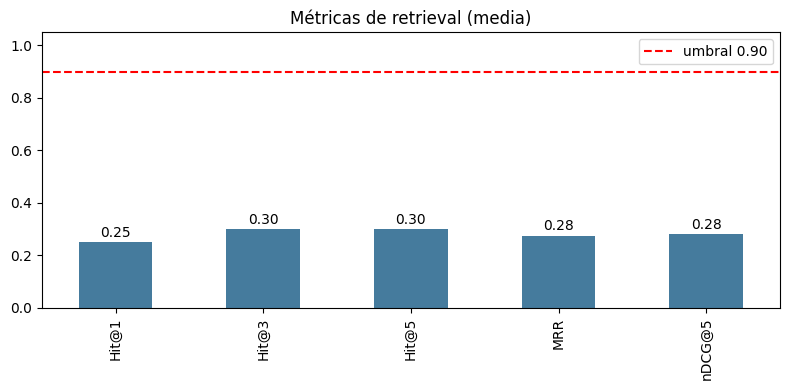

In [4]:
def fila_metricas(r):
    ids, gold = r["retrieved_ids"], r["gold_id"]
    return pd.Series({
        "Hit@1":  hit_at_k(ids, gold, 1),
        "Hit@3":  hit_at_k(ids, gold, 3),
        "Hit@5":  hit_at_k(ids, gold, 5),
        "MRR":    reciprocal_rank(ids, gold),
        "nDCG@5": ndcg_at_k(ids, gold, 5),
    })

met = runs_df.join(runs_df.apply(fila_metricas, axis=1))
cols = ["Hit@1", "Hit@3", "Hit@5", "MRR", "nDCG@5"]

print("── GLOBAL (media sobre todas las ejecuciones) ──")
print(met[cols].mean().round(3).to_string())

print("\n── POR TIPO DE DOCUMENTO ──")
print(met.groupby("doc_type")[cols].mean().round(3).to_string())

ax = met[cols].mean().plot(kind="bar", figsize=(8, 4), color="#457B9D", ylim=(0, 1.05))
ax.set_title("Métricas de retrieval (media)")
ax.axhline(0.90, color="red", ls="--", label="umbral 0.90")
for i, v in enumerate(met[cols].mean()):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
ax.legend(); plt.tight_layout(); plt.show()

## 4.4 Calidad de la respuesta (LLM-as-judge)

Sobre la primera iteración, un juez LLM puntúa de 1 a 5 la **correctitud** y la **fidelidad** de cada respuesta frente al chunk fuente.

In [5]:
gold_by_qid = {q["id"]: q for q in eval_set}

jueces = []
for r in runs_df[runs_df["run"] == 0].itertuples():
    q = gold_by_qid[r.qid]
    j = llm_judge(q["question"], r.answer, q["gold_content"])
    jueces.append({"qid": r.qid, "doc_type": r.doc_type, **j})

judge_df = pd.DataFrame(jueces)
print("Calidad media (1-5):")
print(judge_df[["correctitud", "fidelidad"]].mean().round(2).to_string())
print("\nPor tipo:")
print(judge_df.groupby("doc_type")[["correctitud", "fidelidad"]].mean().round(2).to_string())
judge_df

Calidad media (1-5):
correctitud    2.40
fidelidad      2.65

Por tipo:
           correctitud  fidelidad
doc_type                         
actas             2.80       2.80
contratos         2.00       3.00
normativa         2.25       2.25
proyecto          2.67       3.00


,qid,doc_type,correctitud,fidelidad,motivo
0,1,normativa,1,1,La respuesta del asistente no proporciona la i...
1,2,normativa,5,5,La respuesta del asistente es correcta y se aj...
2,3,normativa,2,2,La respuesta del asistente menciona requisitos...
3,4,normativa,2,2,La respuesta del asistente menciona requisitos...
4,5,normativa,1,1,La respuesta del asistente no aborda la pregun...
5,6,normativa,1,1,La respuesta del asistente no proporciona la i...
6,7,normativa,1,1,La respuesta del asistente no aborda la pregun...
7,8,normativa,5,5,La respuesta del asistente coincide completame...
8,9,actas,1,1,La respuesta del asistente no menciona quién a...
9,10,actas,5,5,La respuesta del asistente coincide exactament...


## 4.5 Consistencia entre iteraciones y latencia

¿El agente es estable? Para cada pregunta miramos si el Hit@5 coincide en todas las iteraciones. También resumimos la latencia end-to-end (incluye clasificación + recuperación + generación).

Preguntas con Hit@5 estable en las 2 iteraciones: 100%

Latencia end-to-end (s):
  media=1.97  ·  p95=2.76  ·  máx=3.62
  todas < 10s: sí


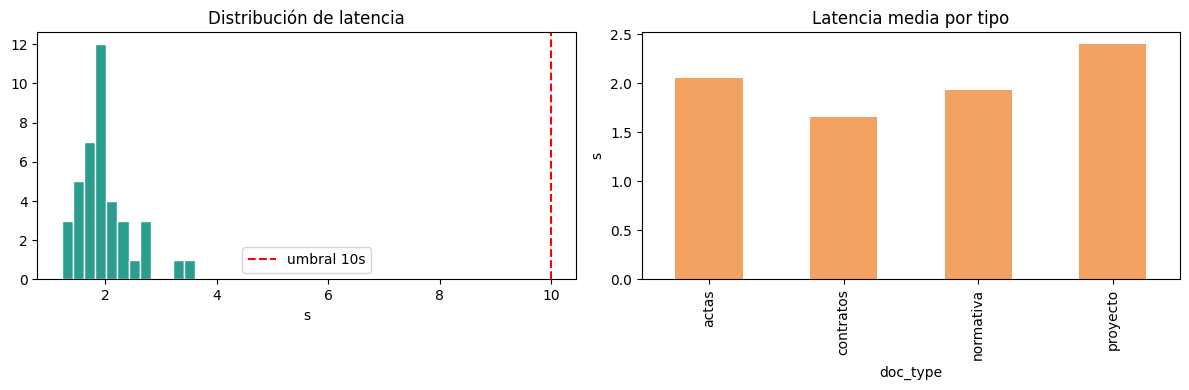

In [6]:
# Consistencia: % de preguntas con Hit@5 idéntico en todas las iteraciones
consist = met.groupby("qid")["Hit@5"].nunique()
estables = (consist == 1).mean()
print(f"Preguntas con Hit@5 estable en las {N_RUNS} iteraciones: {estables*100:.0f}%")

# Latencia end-to-end
lat = runs_df["latency"]
print(f"\nLatencia end-to-end (s):")
print(f"  media={lat.mean():.2f}  ·  p95={lat.quantile(0.95):.2f}  ·  máx={lat.max():.2f}")
print(f"  todas < 10s: {'sí' if (lat < 10).all() else 'no'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lat, bins=12, color="#2A9D8F", edgecolor="white")
axes[0].axvline(10, color="red", ls="--", label="umbral 10s")
axes[0].set_title("Distribución de latencia"); axes[0].set_xlabel("s"); axes[0].legend()

runs_df.groupby("doc_type")["latency"].mean().plot(kind="bar", ax=axes[1], color="#F4A261")
axes[1].set_title("Latencia media por tipo"); axes[1].set_ylabel("s")
plt.tight_layout(); plt.show()

## 4.6 Veredicto frente a las hipótesis del PoC

- **Precisión** = Hit@5 medio (¿está el chunk fuente en el top-5?) vs umbral **> 90%**.
- **Latencia** p95 end-to-end vs umbral **< 10s**.

In [7]:
precision = met["Hit@5"].mean()
p95 = runs_df["latency"].quantile(0.95)

v = verdict(precision, p95)
print("=" * 60)
print("VEREDICTO DEL PoT")
print("=" * 60)
print(f"  Precisión (Hit@5) : {v['precision']:.2%}  (umbral ≥ {v['precision_umbral']:.0%})  → "
      f"{'✓' if v['pasa_precision'] else '✗'}")
print(f"  Latencia p95      : {v['latencia_p95']:.2f}s  (umbral ≤ {v['latencia_umbral']:.0f}s)  → "
      f"{'✓' if v['pasa_latencia'] else '✗'}")
if "judge_df" in dir():
    print(f"  Calidad (corr/fid): {judge_df['correctitud'].mean():.2f} / "
          f"{judge_df['fidelidad'].mean():.2f} (de 5)")
print("=" * 60)
print(f"  {v['veredicto']}")
print("=" * 60)

retriever.close()

VEREDICTO DEL PoT
  Precisión (Hit@5) : 30.00%  (umbral ≥ 90%)  → ✗
  Latencia p95      : 2.76s  (umbral ≤ 10s)  → ✓
  Calidad (corr/fid): 2.40 / 2.65 (de 5)
  🟡 REVISAR / PIVOT
